# Replicating Tigges et al. (2023): a Linear Positive/Negative Direction in Gemma 2 2B

**Reference.** Tigges, Hollinsworth, Geiger, & Nanda (2023), *Linear Representations of Sentiment in Large Language Models* — [arXiv:2310.15154](https://arxiv.org/abs/2310.15154).

This notebook is a standalone sanity check that precedes the ordinal-intensity analysis in [`003_0405_braico.ipynb`](003_0405_braico.ipynb). Restricting our paraphrase corpus to its binary `{negative, positive}` extremes, we re-run the non-causal direction-finding methods the paper used and verify that our setup recovers the same qualitative geometry — sentiment lying on a single linear direction in activation space.

**Structure.**

- **§1** — Setup: imports, plotting style, configuration, data loading.
- **§2** — Pre-computed activations.
- **§R** — Replication: direction estimation, classification, within-scenario centering, adjacent half-steps, and a layer sweep.

## 1. Setup

We rely on three internal modules:

- **`lib.sentences`** — typed `Sample` dataclass and JSONL loaders.
- **`lib.representations`** — readers for the pre-computed per-layer activations.
- **`lib.analysis`** — within-scenario centering helper.

External: NumPy, PyTorch, scikit-learn, Matplotlib.

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.sentences import LEVELS, load_accepted
from lib.representations import load_representations
from lib.analysis import within_center
from lib.plotting import (
    apply_style,
    C_POS, C_NEG, C_NEUT, C_REF, C_NULL,
    plot_agreement, plot_agreement_pair,
    plot_projection, plot_projection_pair,
    plot_layer_sweep,
)

In [ ]:
# Activate the notebook-wide plotting style (rcParams + palette live in lib/plotting.py).
apply_style()

### 1.1 Configuration

| Symbol | Meaning |
|---|---|
| `MODEL` | HuggingFace identifier of the base model. |
| `LAYER` | Focal residual-stream layer for single-layer analyses. |
| `TRAIT` | Trait whose paraphrases populate the corpus. |
| `POOL` | Token-pooling rule used at extraction time (`"mean"` or `"last"`). |
| `ACCEPTED_JSONL` | Paraphrases that passed the blind intensity quality gate. |
| `REP_DIR` | Per-pool directory of `layer_<N>.pt` bundles produced by `extract_representations.py`. |

In [ ]:
MODEL          = "google/gemma-2-2b"
LAYER          = 13
TRAIT          = "politeness"
POOL           = "last"  # token-pooling method used by extract_representations.py
ACCEPTED_JSONL = sorted(Path("../../data").glob("20260530_001930/sentences/sentences_filtered.jsonl"))[-1]
REP_DIR        = ACCEPTED_JSONL.parent.parent / "representations" / POOL  # extract_representations.py output

### 1.2 Data Loading

Each record in `ACCEPTED_JSONL` is one accepted paraphrase, tagged by intensity level and scenario. We deserialize the file and report per-level counts so any obvious imbalance is visible before downstream analyses.

In [ ]:
records_raw = []
with ACCEPTED_JSONL.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records_raw.append(json.loads(line))

levels_present = [lvl for lvl in LEVELS if lvl in {r["level"] for r in records_raw}]
scenarios = {r["scenario_id"] for r in records_raw}

print(f"Loaded {len(records_raw)} accepted paraphrases  |  scenarios: {len(scenarios)}")
print(f"Levels (ordered):           {levels_present}")
for lvl in levels_present:
    texts = [r["text"] for r in records_raw if r["level"] == lvl]
    print(f"  {lvl:<8s} n={len(texts):>4}   e.g. {texts[0][:72]!r}")

Loaded 633 accepted paraphrases  |  scenarios: 72
Levels (ordered):           ['negative', 'neutral', 'positive']
  negative n= 212   e.g. "The food's late, I suppose. Sorry, not my fault, but still, sorry."
  neutral  n= 214   e.g. 'My apologies for the delay; your food is on its way now, thank you.'
  positive n= 207   e.g. 'Please accept my sincerest apologies for the delay and any trouble cause'


### 1.3 Sample Construction

`load_accepted` reads the same file and returns a list of typed `Sample` objects (`prompt`, `trait`, `intensity`, `scenario_id`) — the uniform interface expected by every downstream library function.

In [ ]:
samples = load_accepted(ACCEPTED_JSONL)
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]

## 2. Pre-computed Activations

Activations are extracted offline by [`extract_representations.py`](../extract_representations.py), which writes one `layer_<N>.pt` bundle per layer under `data/<timestamp>/representations/<pool>/`. `load_representations` deserializes them, keyed by `(trait, intensity, scenario_id)` when a specific `layer=` is passed (and by `(trait, intensity, scenario_id, layer)` when it is not).

In [ ]:
activations = load_representations(REP_DIR, layer=LAYER)
print(f"Loaded {len(activations)} activation vectors  |  layer {LAYER}  |  pool '{POOL}'")

Loaded 216 activation vectors  |  layer 13  |  pool 'last'


## R · Replication

We re-test the central claim of Tigges et al. (2023) — that sentiment is encoded along a single linear direction in activation space — using *our* paraphrase corpus restricted to its binary `{negative, positive}` extremes.

**Mapping to our setting.** The paper uses single-template toy reviews and SST; our corpus is matched-scenario paraphrases on an ordinal politeness ladder. To align the two setups we drop `neutral` and keep the extremes — the binary contrast the paper actually studied. The unit of analysis is the per-scenario level mean of pooled content activations at layer `LAYER`.

**Methods reused.** Four of the five direction-finders introduced in the paper's §2.2 — *Mean Difference*, *K-means*, *Logistic Regression*, and the top *PCA* component. DAS is omitted: it is defined by a causal-patching objective outside this notebook's scope. A *Random* direction is added as a noise floor.

**A confound to handle.** The paper's single-template prompts make sentiment the dominant axis of variation, so essentially any direction-finder lands on it. Our corpus is built the opposite way: many distinct scenarios paraphrased up and down a ladder. The dominant axis of variation across the *dataset* is therefore which scenario a vector comes from, not its sentiment, and unsupervised methods tend to lock onto it. §R.3 applies the within-scenario centering precaution that removes this baseline; §R.4 extends the analysis to the adjacent half-steps; §R.5 sweeps every layer.

**Outline.**

- **R.1** — Direction agreement across the four estimators (paper Fig. 2 analogue).
- **R.2** — Classification accuracy and projection separation (Fig. 3 & Fig. 1 analogue).
- **R.3** — Within-scenario centering as a confound control.
- **R.4** — The two adjacent half-steps.
- **R.5** — Layer sweep.

In [ ]:
# Shared building blocks for the replication.
NEG, POS = "negative", "positive"
METHODS = ["MeanDiff", "KMeans", "LogReg", "PCA"]   # paper §2.2 minus DAS
NAMES = METHODS + ["Random"]                         # used wherever the random floor is shown


def binary_table(acts, trait=TRAIT):
    """Return (X, y, scenario_ids) for the {negative, positive} contrast in *acts*."""
    rows, y, scen = [], [], []
    for (t, lvl, sid), vec in acts.items():
        if t != trait or lvl not in (NEG, POS):
            continue
        rows.append(np.asarray(vec, dtype=np.float64))
        y.append(1 if lvl == POS else 0)
        scen.append(sid)
    return np.stack(rows), np.array(y), np.array(scen)


def _unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else v


def direction(method, X, y):
    """Unit sentiment direction estimated by one of the paper's §2.2 methods.

    The vector is oriented so the positive class projects to higher values.
    """
    if method == "MeanDiff":
        d = X[y == 1].mean(0) - X[y == 0].mean(0)
    elif method == "KMeans":
        c = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X).cluster_centers_
        d = c[1] - c[0]
    elif method == "LogReg":
        d = LogisticRegression(max_iter=2000).fit(X, y).coef_[0]
    elif method == "PCA":
        d = PCA(n_components=1, random_state=0).fit(X).components_[0]
    elif method == "Random":
        d = np.random.default_rng(0).standard_normal(X.shape[1])
    else:
        raise ValueError(method)
    d = _unit(d)
    if (X[y == 1] @ d).mean() < (X[y == 0] @ d).mean():
        d = -d
    return d


def cosine_matrix(dir_dict, order):
    """All-pairs cosine of unit directions in `dir_dict`, ordered as `order`."""
    return np.array([[float(dir_dict[a] @ dir_dict[b]) for b in order] for a in order])


Xb, yb, scen_b = binary_table(activations)
print(
    f"Binary contrast at layer {LAYER}: "
    f"{Xb.shape[0]} vectors ({int((yb == 1).sum())} pos / {int((yb == 0).sum())} neg) "
    f"over {len(set(scen_b))} scenarios  |  dim={Xb.shape[1]}"
)

Binary contrast at layer 13: 144 vectors (72 pos / 72 neg) over 72 scenarios  |  dim=2304


### R.1 — Direction agreement across estimators

The paper's first observation is that several different direction-finders recover the *same* axis (Fig. 2). We replicate this with the four §2.2 methods plus a Random floor and report the all-pairs cosine similarity of the estimated unit directions. Under the linear-direction hypothesis, the non-random methods should cluster near +1.

(<Figure size 1000x900 with 2 Axes>,
 <Axes: title={'center': 'Direction agreement across estimators'}>)

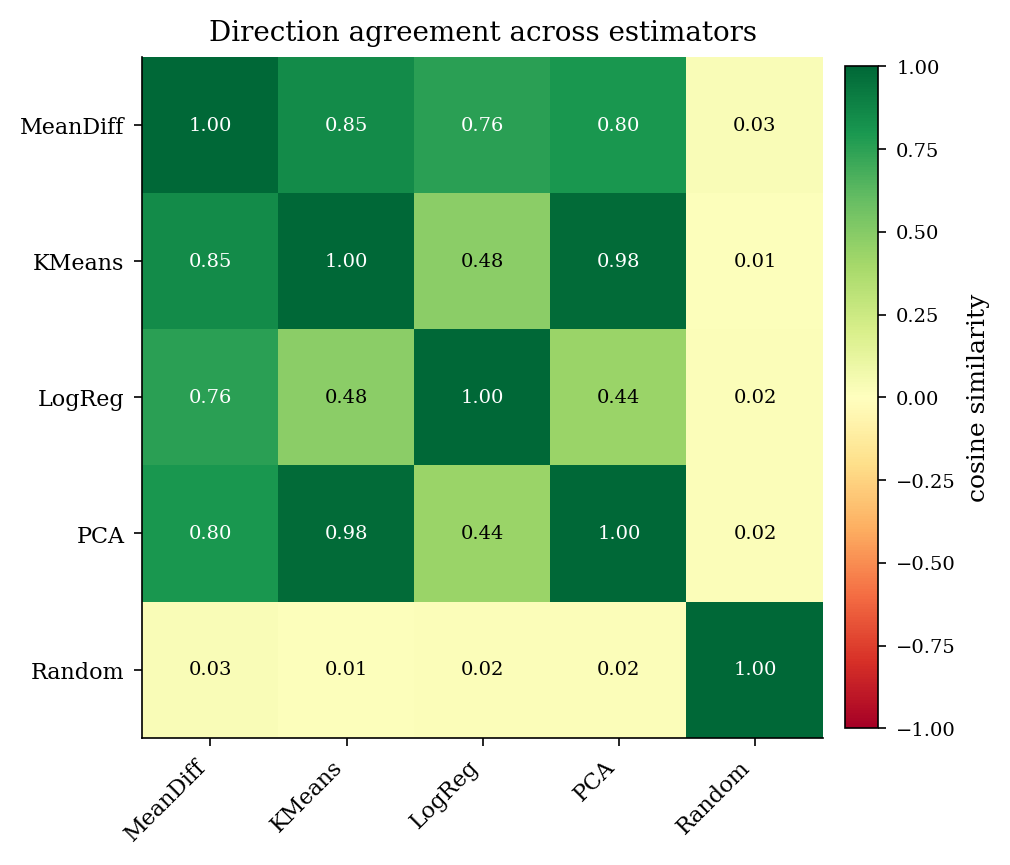

In [ ]:
# R.1 — Pairwise cosine similarity of the four §2.2 directions (Random as floor).
dirs_b = {m: direction(m, Xb, yb) for m in NAMES}
C = cosine_matrix(dirs_b, NAMES)

plot_agreement(C, NAMES, "Direction agreement across estimators")

### R.2 — Classification by projection

If sentiment lies on a single linear direction, projecting onto that direction and thresholding at the midpoint should yield a working classifier. We measure this two ways.

- **Cross-validated balanced accuracy.** A scenario-grouped `GroupKFold` keeps a scenario's two halves from straddling the train/test split. The direction and threshold are fit on the training scenarios only and then applied to the held-out ones. The paper's Figure-3 GPT2-small layer-0 accuracies are printed alongside for reference.
- **Projection histogram.** Distribution of projections by class along the Mean-Difference axis — the analogue of the paper's Figure 1 — summarized by ROC-AUC and Cohen's *d*.

   method   bal-acc    ±SD    paper Fig.3 (GPT2-small L0)
----------------------------------------------------
 MeanDiff     0.944  0.066    .80
   KMeans     0.827  0.060    .78
   LogReg     0.980  0.027    .89
      PCA     0.778  0.064    .81

Mean-Difference axis: AUC=0.988, Cohen's d=3.58


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Projection separation at layer 13'}, xlabel='projection onto Mean-Difference axis', ylabel='scenarios'>)

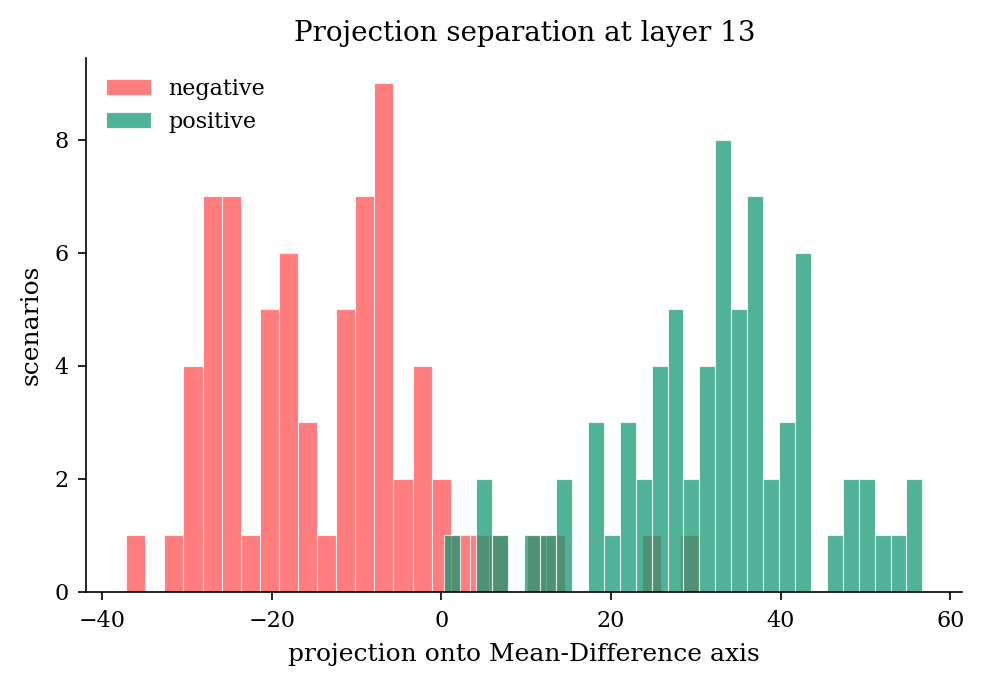

In [ ]:
# R.2 — Direction-as-classifier (paper Fig. 3) and projection separation (Fig. 1).
def cv_direction_accuracy(method, X, y, groups, n_splits=5):
    """Mean ± SD balanced accuracy of the projection-threshold classifier under
    scenario-grouped K-fold CV. Direction and threshold are fit on the training
    fold; a held-out scenario is labelled by which side of the threshold its
    projection falls on.
    """
    gkf = GroupKFold(n_splits=min(n_splits, len(set(groups))))
    accs = []
    for tr, te in gkf.split(X, y, groups):
        d = direction(method, X[tr], y[tr])
        thr = 0.5 * ((X[tr][y[tr] == 1] @ d).mean() + (X[tr][y[tr] == 0] @ d).mean())
        accs.append(balanced_accuracy_score(y[te], (X[te] @ d > thr).astype(int)))
    return float(np.mean(accs)), float(np.std(accs))


def projection_stats(X, y, axis):
    """Per-vector projection onto `axis` plus ROC-AUC and Cohen's d."""
    proj = X @ axis
    auc = roc_auc_score(y, proj)
    pooled_sd = np.sqrt(0.5 * (proj[y == 1].var(ddof=1) + proj[y == 0].var(ddof=1)))
    d = (proj[y == 1].mean() - proj[y == 0].mean()) / pooled_sd if pooled_sd > 0 else float("inf")
    return proj, auc, d


PAPER_REF = {"MeanDiff": ".80", "KMeans": ".78", "LogReg": ".89", "PCA": ".81"}
print(f"{'method':>9} {'bal-acc':>9} {'±SD':>6}    paper Fig.3 (GPT2-small L0)")
print("-" * 52)
for m in METHODS:
    mu, sd = cv_direction_accuracy(m, Xb, yb, scen_b)
    print(f"{m:>9} {mu:>9.3f} {sd:>6.3f}    {PAPER_REF[m]}")

axis_md = direction("MeanDiff", Xb, yb)
proj, auc, cohen_d = projection_stats(Xb, yb, axis_md)
print(f"\nMean-Difference axis: AUC={auc:.3f}, Cohen's d={cohen_d:.2f}")

plot_projection(
    proj, yb,
    neg_label="negative", pos_label="positive",
    title=f"Projection separation at layer {LAYER}",
)

### R.3 — Removing the scenario confound: within-scenario centering

§R.1 and §R.2 used the raw activations. Each scenario contributes a baseline (language, topic, invariant content) shared by its `negative` and `positive` halves, and that baseline dominates the variance — biasing the unsupervised estimators toward the scenario axis rather than the sentiment axis.

The fix mirrors §5 of [`003_0405_braico.ipynb`](003_0405_braico.ipynb): the **within-scenario (fixed-effects) transform**, implemented by `within_center`. It subtracts each scenario's own two-level mean, so a scenario's two centered vectors become exactly antipodal — $\pm\tfrac{1}{2}(\text{positive} - \text{negative})$ — and the only variance left across the dataset is the sentiment shift itself.

We rerun §R.1's direction-agreement matrix and §R.2's projection-separation histogram on the centered activations and place each side-by-side with its raw-activation counterpart.

### R.4 — Adjacent half-steps

Tigges et al. studied only the extreme `{negative, positive}` contrast. Because politeness is *ordinal*, a sharper test is whether each adjacent half-step carries the same linear structure as the full span. We repeat §R.3's raw-vs-centered diagnostics on the two adjacent contrasts:

- `neutral → positive` — the polite half-step;
- `negative → neutral` — the impolite half-step.

Each half-step covers a smaller shift than the full extremes contrast, so the raw values may be noisier; the comparison of interest is the *shape change* between raw and centered, not the absolute level.

positive vs. neutral  (layer 13)
  raw:      144 vectors / 72 scenarios
  centered: 144 vectors / 72 complete scenarios

     method       raw   centered
  ------------------------------
   MeanDiff     0.815      0.905
     KMeans     0.534      0.905
     LogReg     0.869      0.973
        PCA     0.534      0.877
neutral vs. negative  (layer 13)
  raw:      144 vectors / 72 scenarios
  centered: 144 vectors / 72 complete scenarios

     method       raw   centered
  ------------------------------
   MeanDiff     0.923      1.000
     KMeans     0.806      1.000
     LogReg     0.966      1.000
        PCA     0.757      1.000


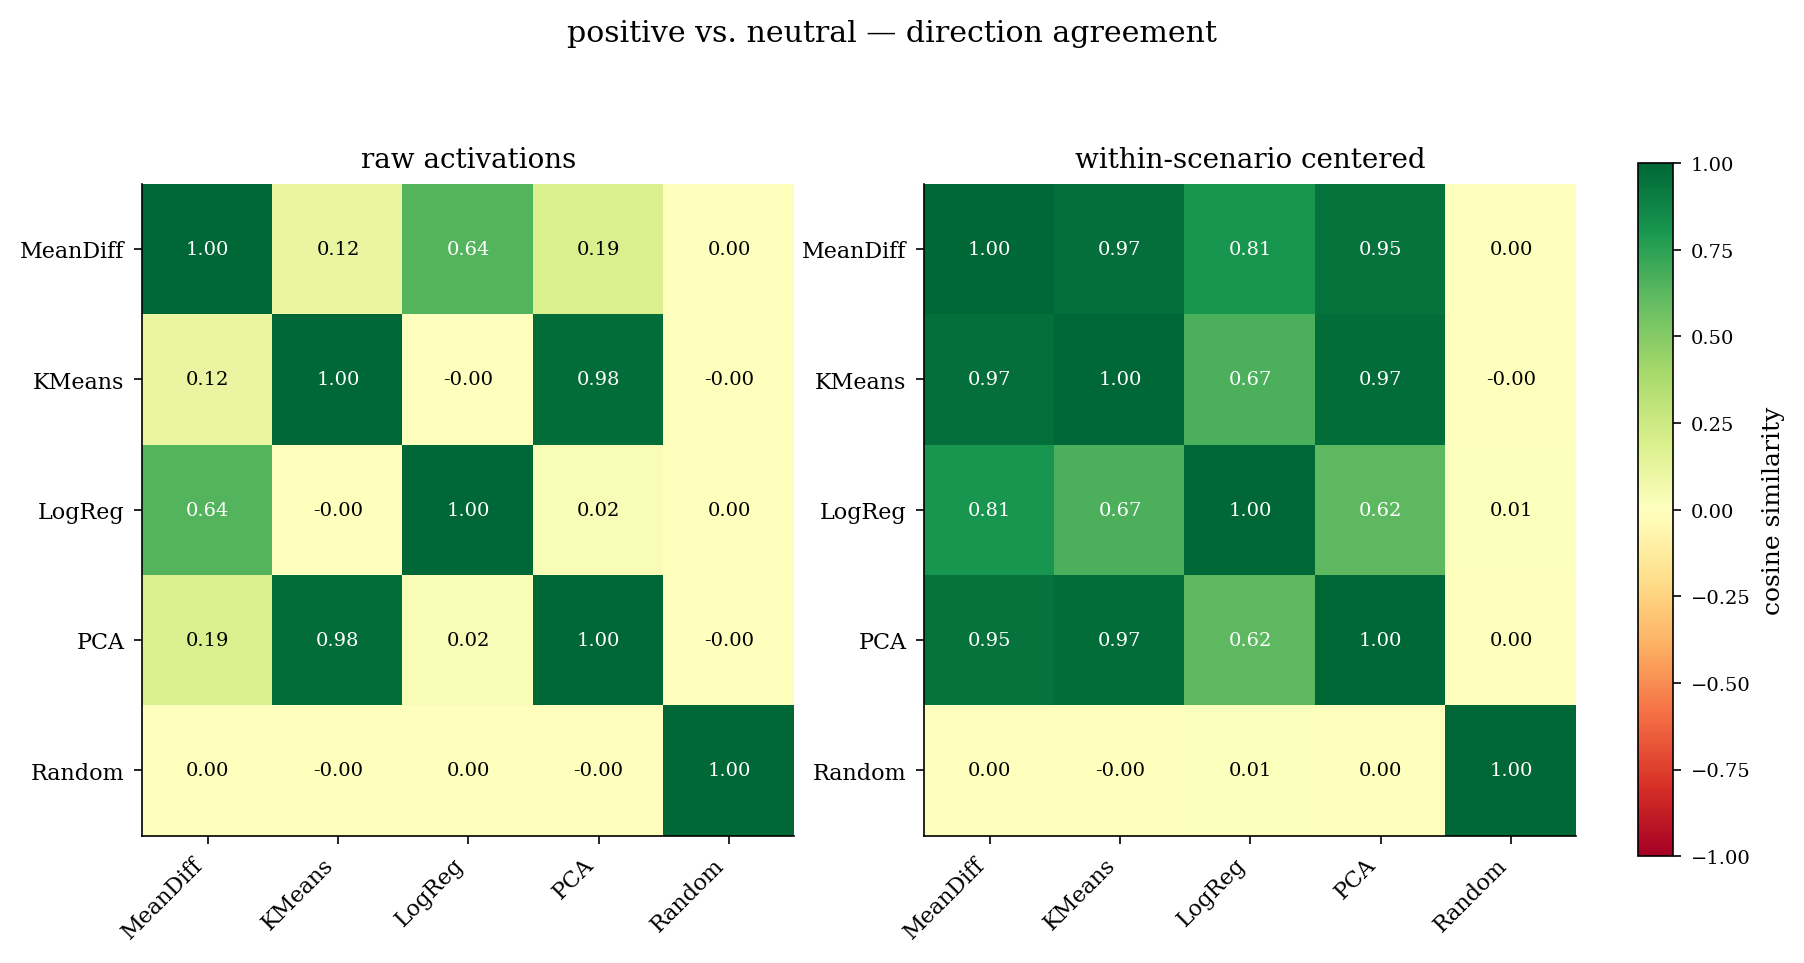

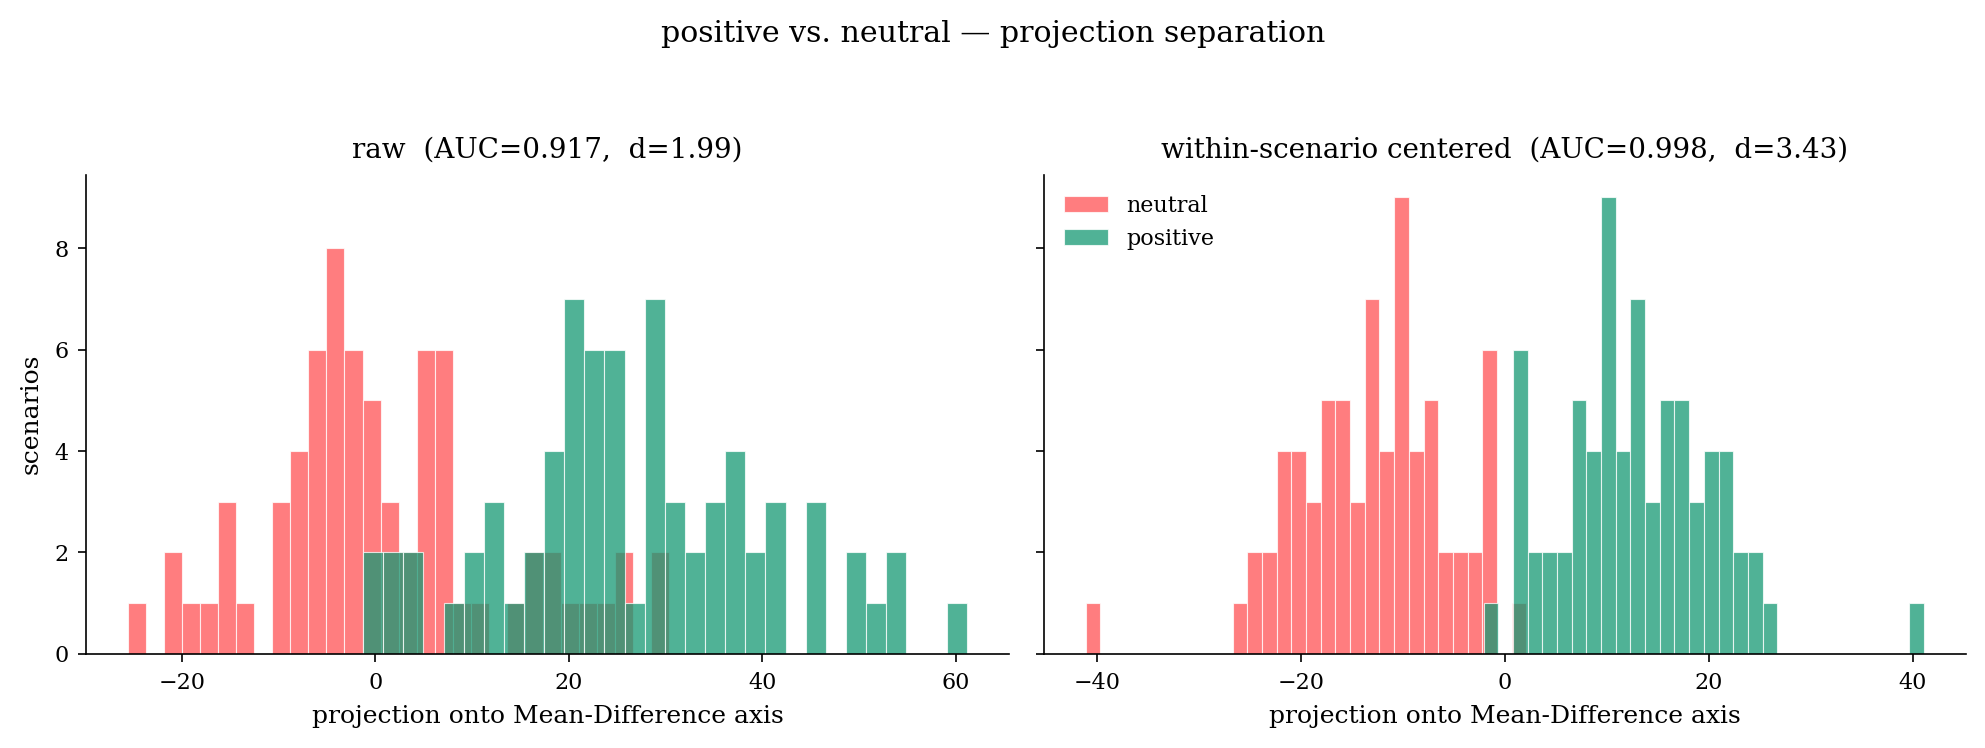

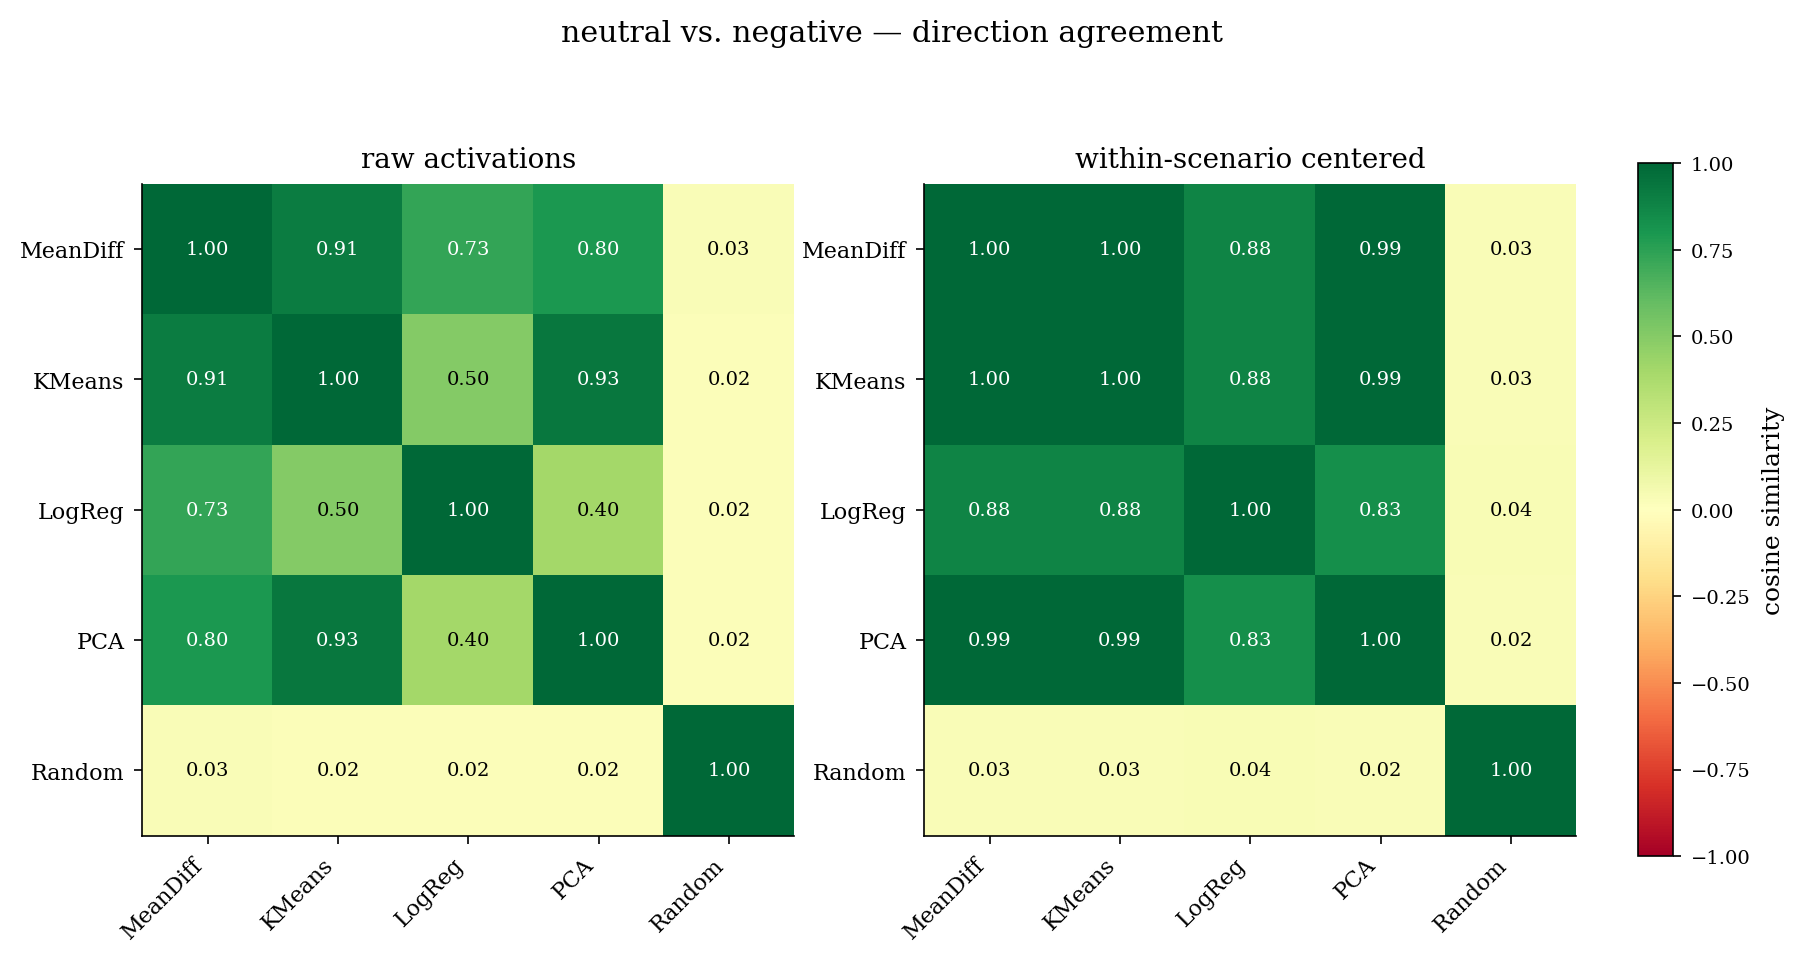

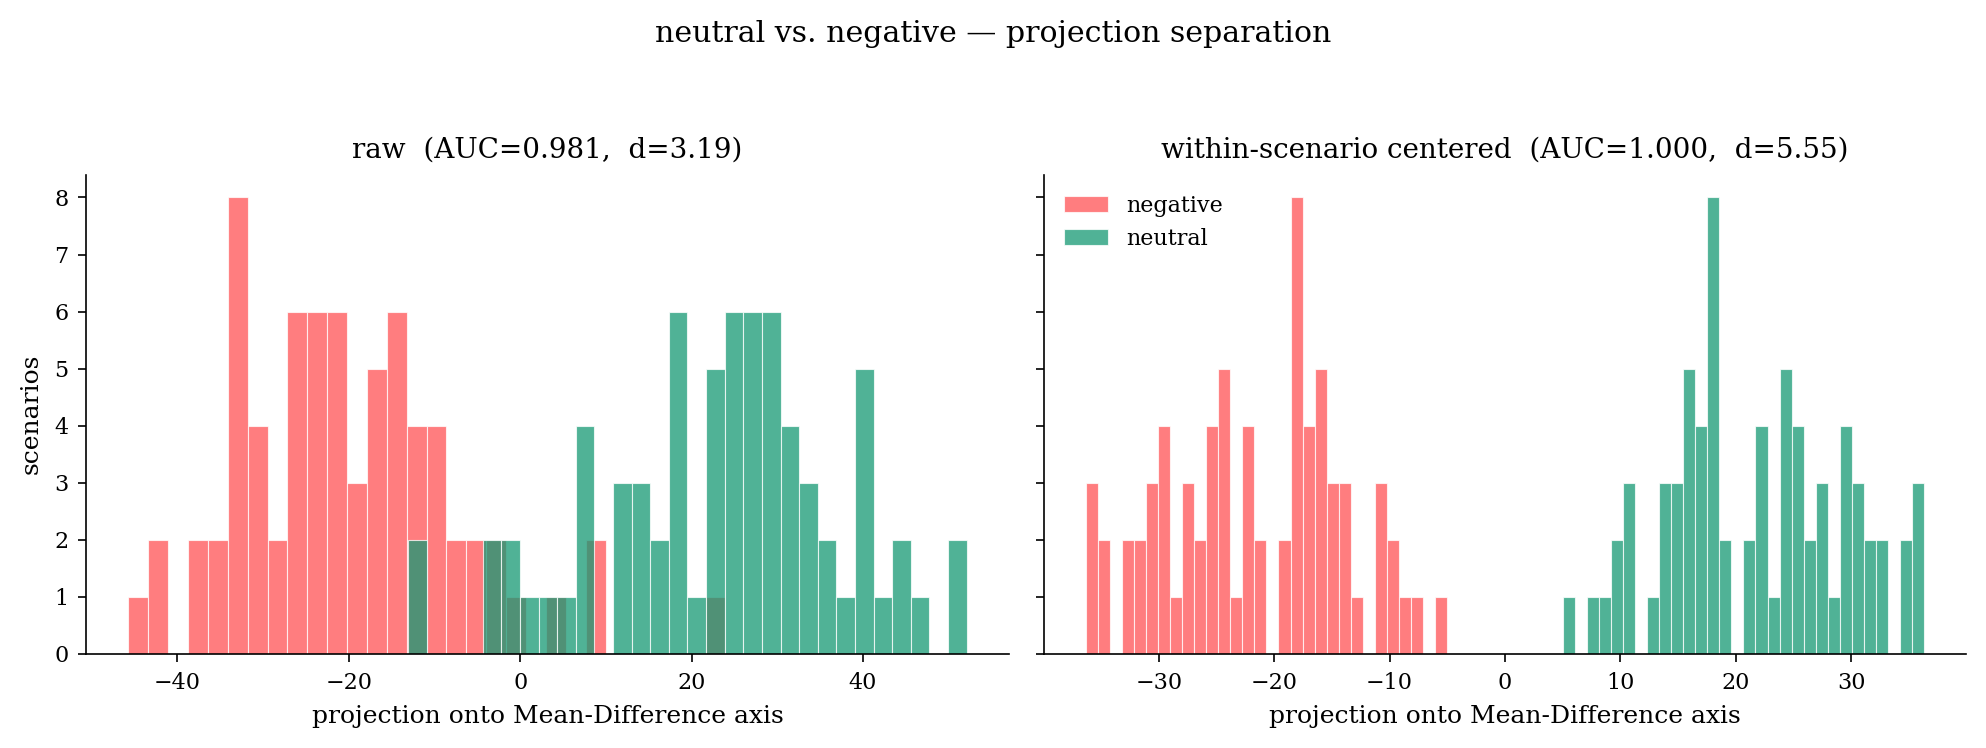

In [ ]:
# R.4 — Repeat R.3's raw-vs-centered diagnostics on the two adjacent half-steps.
PAIRS = [("neutral", "positive"), ("negative", "neutral")]


def pair_table(acts, lo, hi, trait=TRAIT):
    """(X, y, scenarios) for a (lo, hi) contrast, y=1 for the *hi* level."""
    rows, y, scen = [], [], []
    for (t, lvl, sid), vec in acts.items():
        if t != trait or lvl not in (lo, hi):
            continue
        rows.append(np.asarray(vec, dtype=np.float64))
        y.append(1 if lvl == hi else 0)
        scen.append(sid)
    return np.stack(rows), np.array(y), np.array(scen)


for lo, hi in PAIRS:
    Xr, yr, scen_r = pair_table(activations, lo, hi)
    Xk, yk, scen_k = pair_table(within_center(activations, [lo, hi], trait=TRAIT), lo, hi)

    print("=" * 60)
    print(f"{hi} vs. {lo}  (layer {LAYER})")
    print(f"  raw:      {Xr.shape[0]} vectors / {len(set(scen_r))} scenarios")
    print(f"  centered: {Xk.shape[0]} vectors / {len(set(scen_k))} complete scenarios")

    dr = {m: direction(m, Xr, yr) for m in NAMES}
    dk = {m: direction(m, Xk, yk) for m in NAMES}
    Cr = cosine_matrix(dr, NAMES)
    Ck = cosine_matrix(dk, NAMES)

    print(f"\n  {'method':>9} {'raw':>9} {'centered':>10}")
    print("  " + "-" * 30)
    for m in METHODS:
        r = cv_direction_accuracy(m, Xr, yr, scen_r)[0]
        k = cv_direction_accuracy(m, Xk, yk, scen_k)[0]
        print(f"  {m:>9} {r:>9.3f} {k:>10.3f}")

    plot_agreement_pair(
        matrices=[Cr, Ck],
        titles=["raw activations", "within-scenario centered"],
        names=NAMES,
        suptitle=f"{hi} vs. {lo} — direction agreement",
    )

    pr, aucr, cdr = projection_stats(Xr, yr, direction("MeanDiff", Xr, yr))
    pk, auck, cdk = projection_stats(Xk, yk, direction("MeanDiff", Xk, yk))
    plot_projection_pair(
        panels=[(pr, yr), (pk, yk)],
        titles=[f"raw  (AUC={aucr:.3f},  d={cdr:.2f})",
                f"within-scenario centered  (AUC={auck:.3f},  d={cdk:.2f})"],
        neg_label=lo, pos_label=hi,
        suptitle=f"{hi} vs. {lo} — projection separation",
    )

### R.5 — Layer sweep

The paper recovers a sentiment direction at every layer. We re-estimate the direction at each layer present in the activation bundles and plot two summaries against layer index:

- **Mean-Difference scenario-grouped CV balanced accuracy** — how separable the classes are along the supervised axis at that layer.
- **Mean pairwise cosine** across the four §R.1 estimators — how much they agree on a single direction at that layer.

The focal layer used in §R.1–R.4 is marked for reference.

Loaded 22-layer sweep from ../../data/20260530_001930/representations/last


(<Figure size 1080x560 with 1 Axes>,
 <Axes: title={'center': 'Linear positive/negative structure across layers'}, xlabel='layer', ylabel='score'>)

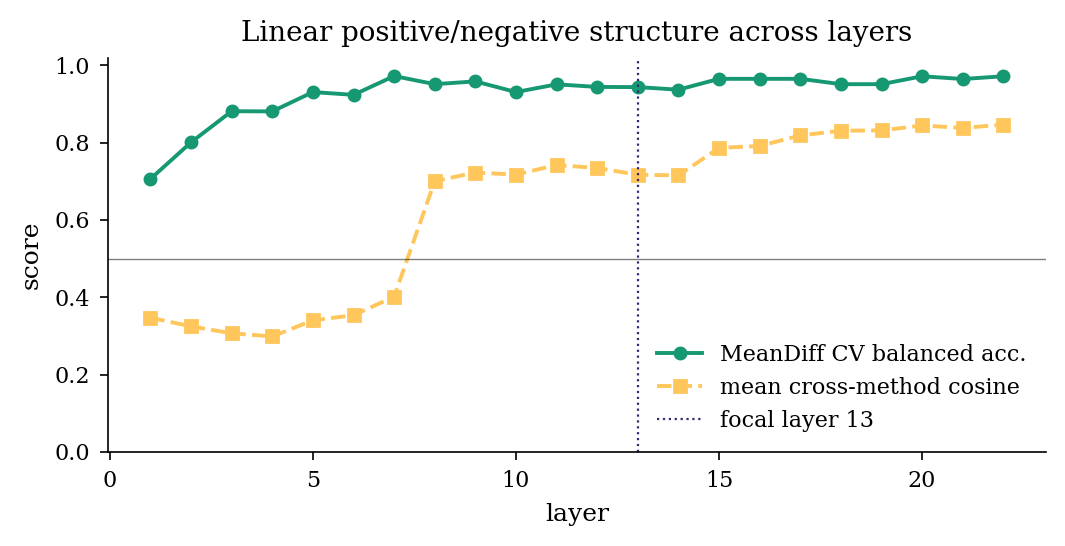

In [ ]:
# R.5 — Direction quality vs. layer. One re-estimation per layer.
acts_multi = load_representations(REP_DIR)
rep_layers = sorted({l for (_, _, _, l) in acts_multi})
print(f"Loaded {len(rep_layers)}-layer sweep from {REP_DIR}")

sweep_acc, sweep_cos = [], []
for L in rep_layers:
    aL = {(t, i, s): v for (t, i, s, l), v in acts_multi.items() if l == L}
    X, y, scen = binary_table(aL)
    sweep_acc.append(cv_direction_accuracy("MeanDiff", X, y, scen)[0])
    dset = {m: direction(m, X, y) for m in METHODS}
    sweep_cos.append(
        float(np.mean([dset[a] @ dset[b] for a in METHODS for b in METHODS if a < b]))
    )

plot_layer_sweep(rep_layers, sweep_acc, sweep_cos, focal_layer=LAYER)